In [1]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import folium
from folium.features import GeoJsonTooltip
import json
import geopandas as gpd

In [2]:
#Loading the data
PHD_final = pd.read_csv("C:/Users/HomePC/Desktop/CSA2025/Group1-Healthcare_Access_Inequality_Predictor/Data/Pop_health_data_final.csv")
#Displaying the first five rows in the dataframe
PHD_final.head()

,Unnamed: 0,county,pop_total,number_of_beds,facility_catchment_population,no._of_facilities,access_score,beds_per_1000,access_level,access_flag
0,0,Baringo,666763,334,204309.0,41,0.000061,0.500928,Low,Underserved
1,1,Bomet,875689,259,398032.0,77,0.000088,0.295767,Low,Low Moderate
2,2,Bungoma,1670570,1453,1342280.0,129,0.000077,0.869763,Low,Low Moderate
3,3,Busia,893681,826,243454.0,35,0.000039,0.924267,Low,Underserved
4,4,Elgeyo/Marakwet,454480,329,108943.0,25,0.000055,0.723904,Low,Underserved


In [3]:
#Dropping the unamed column
PHD_final.drop(columns=['Unnamed: 0'], inplace = True)
#Displaying the first five rows in the dataframe
PHD_final.head()

,county,pop_total,number_of_beds,facility_catchment_population,no._of_facilities,access_score,beds_per_1000,access_level,access_flag
0,Baringo,666763,334,204309.0,41,0.000061,0.500928,Low,Underserved
1,Bomet,875689,259,398032.0,77,0.000088,0.295767,Low,Low Moderate
2,Bungoma,1670570,1453,1342280.0,129,0.000077,0.869763,Low,Low Moderate
3,Busia,893681,826,243454.0,35,0.000039,0.924267,Low,Underserved
4,Elgeyo/Marakwet,454480,329,108943.0,25,0.000055,0.723904,Low,Underserved


In [4]:
# Define feature columns for modeling healthcare access
features = ['pop_total', 'number_of_beds', 'facility_catchment_population', 
            'no._of_facilities', 'beds_per_1000']
# Define target variable
target = 'access_score'  # or 'underserved_label' if binary


X = PHD_final[features] # Feature matrix
y = PHD_final[target]  # Target variable

# Split data into training and testing sets (80/20 split)
# - random_state ensures reproducibility
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
# Initialize regression models
lr_model = LinearRegression()  # - LinearRegression: baseline model for predicting access_score
rf_model = RandomForestRegressor(random_state=42) # - RandomForestRegressor: ensemble model capturing non-linear relationships


# Train both models on the training data
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Store models with names for easy iteration and comparison
models = [('Linear Regression', lr_model), ('Random Forest', rf_model)]

# Evaluate on the test set
for name, model in models:
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)  # - MAE: Mean Absolute Error (average magnitude of errors)
    rmse = np.sqrt(mean_squared_error(y_test, preds)) # - RMSE: Root Mean Squared Error (penalizes larger errors)
    r2   = r2_score(y_test, preds) # - R²: Coefficient of Determination (explained variance)
    
    print(f"{name} — Healthcare Inequality Predictor:")
    print(f"  MAE  = {mae:.2f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  R²   = {r2:.3f}")
    print("-" * 40)


Linear Regression — Healthcare Inequality Predictor:
  MAE  = 0.00
  RMSE = 0.00
  R²   = -0.140
----------------------------------------
Random Forest — Healthcare Inequality Predictor:
  MAE  = 0.00
  RMSE = 0.00
  R²   = 0.430
----------------------------------------


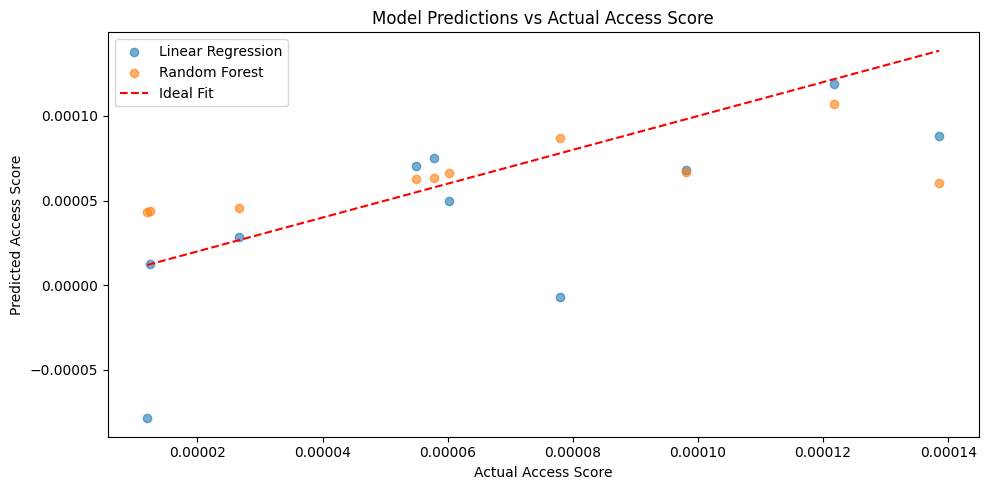

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(10,5))

# Visualize model predictions vs actual access scores
for name, model in models:
    preds = model.predict(X_test)
    plt.scatter(y_test, preds, label=name, alpha=0.6) # - Each model's predictions are plotted with transparency for overlap clarity

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit') #Red dashed line represents the ideal fit (perfect prediction line)
plt.xlabel("Actual Access Score")
plt.ylabel("Predicted Access Score")
plt.title("Model Predictions vs Actual Access Score")
plt.legend()
plt.tight_layout()
plt.show()

plt.savefig("../data/output/Model Predictions vs Actual Access Scores.png")


In [17]:
#Save the figure
plt.savefig("../data/output/Model Predictions vs Actual Access Scores.png")

<Figure size 640x480 with 0 Axes>

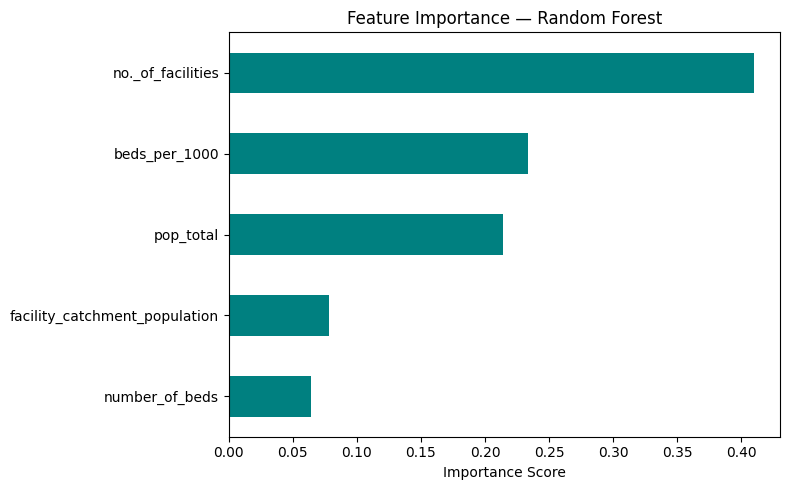

In [18]:
feature_importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8,5))
feature_importance.plot(kind='barh', color='teal')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [ ]:
#Save the figure
fig.savefig("../data/output/Feature Importance — Random Forest.png")

In [19]:

# Perform 5-fold cross-validation to assess model generalizability
for name, model in models:
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f"{name} CV R²: {scores.mean():.3f} ± {scores.std():.3f}")


Linear Regression CV R²: 0.536 ± 0.242
Random Forest CV R²: 0.467 ± 0.123


In [ ]:
PHD_final.head()

In [20]:
import geopandas as gpd
import folium
from folium import Choropleth, GeoJsonTooltip


In [21]:
counties = gpd.read_file('C:/Users/HomePC/Desktop/CSA2025/Group1-Healthcare_Access_Inequality_Predictor/kenyan-counties')
counties

,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,COUNTY,Shape_Leng,Shape_Area,geometry
0,1,5.677,15.047,2.0,1.0,Turkana,15.046838,5.676985,"POLYGON ((35.79593 5.34449, 35.79659 5.34468, ..."
1,2,6.177,11.974,3.0,2.0,Marsabit,11.974165,6.176831,"POLYGON ((36.05061 4.45622, 36.23184 4.45124, ..."
2,3,2.117,7.355,4.0,3.0,Mandera,7.355154,2.117196,"POLYGON ((41.62133 3.97673, 41.62272 3.9786, 4..."
3,4,4.610,9.838,5.0,4.0,Wajir,9.838408,4.609589,"POLYGON ((39.31812 3.47197, 39.31956 3.47168, ..."
4,5,0.740,5.030,6.0,5.0,West Pokot,5.030271,0.740481,"POLYGON ((35.12745 2.62271, 35.12762 2.62302, ..."
5,6,1.713,8.311,7.0,6.0,Samburu,8.311013,1.713014,"POLYGON ((36.73652 2.51379, 36.73706 2.51398, ..."
6,7,2.060,10.181,8.0,7.0,Isiolo,10.181411,2.059820,"POLYGON ((37.94529 1.26288, 38.33966 1.57742, ..."
7,8,0.877,5.964,9.0,8.0,Baringo,5.964266,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3..."
8,9,0.245,4.064,10.0,9.0,Keiyo-Marakwet,4.063527,0.245208,"POLYGON ((35.7028 1.24649, 35.70271 1.24591, 3..."
9,10,0.202,2.387,11.0,10.0,Trans Nzoia,2.387265,0.201983,"POLYGON ((34.82016 1.25983, 34.82024 1.26042, ..."


In [22]:
#Remaning the county name 
counties = counties.rename(columns={'COUNTY': 'county'})
counties.head()

,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,county,Shape_Leng,Shape_Area,geometry
0,1,5.677,15.047,2.0,1.0,Turkana,15.046838,5.676985,"POLYGON ((35.79593 5.34449, 35.79659 5.34468, ..."
1,2,6.177,11.974,3.0,2.0,Marsabit,11.974165,6.176831,"POLYGON ((36.05061 4.45622, 36.23184 4.45124, ..."
2,3,2.117,7.355,4.0,3.0,Mandera,7.355154,2.117196,"POLYGON ((41.62133 3.97673, 41.62272 3.9786, 4..."
3,4,4.610,9.838,5.0,4.0,Wajir,9.838408,4.609589,"POLYGON ((39.31812 3.47197, 39.31956 3.47168, ..."
4,5,0.740,5.030,6.0,5.0,West Pokot,5.030271,0.740481,"POLYGON ((35.12745 2.62271, 35.12762 2.62302, ..."


In [23]:
#Remaning Elgeiyo marakwet that was misspelled
counties['county'] = counties['county'].replace({'Keiyo-Marakwet':'Elgeyo Marakwet'})
counties.head()

,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,county,Shape_Leng,Shape_Area,geometry
0,1,5.677,15.047,2.0,1.0,Turkana,15.046838,5.676985,"POLYGON ((35.79593 5.34449, 35.79659 5.34468, ..."
1,2,6.177,11.974,3.0,2.0,Marsabit,11.974165,6.176831,"POLYGON ((36.05061 4.45622, 36.23184 4.45124, ..."
2,3,2.117,7.355,4.0,3.0,Mandera,7.355154,2.117196,"POLYGON ((41.62133 3.97673, 41.62272 3.9786, 4..."
3,4,4.610,9.838,5.0,4.0,Wajir,9.838408,4.609589,"POLYGON ((39.31812 3.47197, 39.31956 3.47168, ..."
4,5,0.740,5.030,6.0,5.0,West Pokot,5.030271,0.740481,"POLYGON ((35.12745 2.62271, 35.12762 2.62302, ..."


In [24]:
#Sorting counties in alphabetical order
counties_sorted = counties.sort_values(by='county')
counties_sorted.head()

,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,county,Shape_Leng,Shape_Area,geometry
7,8,0.877,5.964,9.0,8.0,Baringo,5.964266,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3..."
31,32,0.229,2.632,33.0,32.0,Bomet,2.631657,0.229037,"POLYGON ((35.32763 -0.40701, 35.32771 -0.40674..."
10,11,0.246,3.076,12.0,11.0,Bungoma,3.075944,0.245741,"POLYGON ((34.58077 1.15033, 34.61261 1.10971, ..."
15,16,0.148,2.683,17.0,16.0,Busia,2.682712,0.147514,"POLYGON ((34.43332 0.7357, 34.43318 0.7352, 34..."
8,9,0.245,4.064,10.0,9.0,Elgeyo Marakwet,4.063527,0.245208,"POLYGON ((35.7028 1.24649, 35.70271 1.24591, 3..."


In [25]:
#Reseting the index
counties_sorted.reset_index(inplace=True)
counties_sorted.head()

,index,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,county,Shape_Leng,Shape_Area,geometry
0,7,8,0.877,5.964,9.0,8.0,Baringo,5.964266,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3..."
1,31,32,0.229,2.632,33.0,32.0,Bomet,2.631657,0.229037,"POLYGON ((35.32763 -0.40701, 35.32771 -0.40674..."
2,10,11,0.246,3.076,12.0,11.0,Bungoma,3.075944,0.245741,"POLYGON ((34.58077 1.15033, 34.61261 1.10971, ..."
3,15,16,0.148,2.683,17.0,16.0,Busia,2.682712,0.147514,"POLYGON ((34.43332 0.7357, 34.43318 0.7352, 34..."
4,8,9,0.245,4.064,10.0,9.0,Elgeyo Marakwet,4.063527,0.245208,"POLYGON ((35.7028 1.24649, 35.70271 1.24591, 3..."


In [26]:
#Dropping unwanted column
counties_sorted.drop(columns =['index'],inplace=True)
counties_sorted.head()

,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,county,Shape_Leng,Shape_Area,geometry
0,8,0.877,5.964,9.0,8.0,Baringo,5.964266,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3..."
1,32,0.229,2.632,33.0,32.0,Bomet,2.631657,0.229037,"POLYGON ((35.32763 -0.40701, 35.32771 -0.40674..."
2,11,0.246,3.076,12.0,11.0,Bungoma,3.075944,0.245741,"POLYGON ((34.58077 1.15033, 34.61261 1.10971, ..."
3,16,0.148,2.683,17.0,16.0,Busia,2.682712,0.147514,"POLYGON ((34.43332 0.7357, 34.43318 0.7352, 34..."
4,9,0.245,4.064,10.0,9.0,Elgeyo Marakwet,4.063527,0.245208,"POLYGON ((35.7028 1.24649, 35.70271 1.24591, 3..."


In [27]:
#Combining the health data with the counties data for mapping
Final_data = pd.concat([PHD_final,counties_sorted],axis=1)
Final_data.head()

,county,pop_total,number_of_beds,facility_catchment_population,no._of_facilities,access_score,beds_per_1000,access_level,access_flag,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,county,Shape_Leng,Shape_Area,geometry
0,Baringo,666763,334,204309.0,41,0.000061,0.500928,Low,Underserved,8,0.877,5.964,9.0,8.0,Baringo,5.964266,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3..."
1,Bomet,875689,259,398032.0,77,0.000088,0.295767,Low,Low Moderate,32,0.229,2.632,33.0,32.0,Bomet,2.631657,0.229037,"POLYGON ((35.32763 -0.40701, 35.32771 -0.40674..."
2,Bungoma,1670570,1453,1342280.0,129,0.000077,0.869763,Low,Low Moderate,11,0.246,3.076,12.0,11.0,Bungoma,3.075944,0.245741,"POLYGON ((34.58077 1.15033, 34.61261 1.10971, ..."
3,Busia,893681,826,243454.0,35,0.000039,0.924267,Low,Underserved,16,0.148,2.683,17.0,16.0,Busia,2.682712,0.147514,"POLYGON ((34.43332 0.7357, 34.43318 0.7352, 34..."
4,Elgeyo/Marakwet,454480,329,108943.0,25,0.000055,0.723904,Low,Underserved,9,0.245,4.064,10.0,9.0,Elgeyo Marakwet,4.063527,0.245208,"POLYGON ((35.7028 1.24649, 35.70271 1.24591, 3..."


In [28]:
#Deleting the duplicated columns
Final_data = Final_data.loc[:, ~Final_data.columns.duplicated()]
Final_data.head(3)

,county,pop_total,number_of_beds,facility_catchment_population,no._of_facilities,access_score,beds_per_1000,access_level,access_flag,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,Shape_Leng,Shape_Area,geometry
0,Baringo,666763,334,204309.0,41,0.000061,0.500928,Low,Underserved,8,0.877,5.964,9.0,8.0,5.964266,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3..."
1,Bomet,875689,259,398032.0,77,0.000088,0.295767,Low,Low Moderate,32,0.229,2.632,33.0,32.0,2.631657,0.229037,"POLYGON ((35.32763 -0.40701, 35.32771 -0.40674..."
2,Bungoma,1670570,1453,1342280.0,129,0.000077,0.869763,Low,Low Moderate,11,0.246,3.076,12.0,11.0,3.075944,0.245741,"POLYGON ((34.58077 1.15033, 34.61261 1.10971, ..."


In [29]:
# Changing the dataframe into a geodataframe
Final_data = gpd.GeoDataFrame(Final_data, geometry='geometry')


In [ ]:
# Create base map centered on Kenya
m = folium.Map(location=[0.0236, 37.9062], zoom_start=6)

# Convert merged GeoDataFrame to GeoJSON
geojson_data = Final_data.to_json()

# Add choropleth layer based on access_score
folium.Choropleth(
    geo_data=geojson_data,
    name='Access Score',
    data=merged,
    columns=['county', 'access_score'],
    key_on='feature.properties.county',
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Healthcare Access Score'
).add_to(m)

# Add tooltips showing county and access_flag
folium.GeoJson(
    geojson_data,
    name='Access Category',
    tooltip=GeoJsonTooltip(
        fields=['county', 'access_flag'],
        aliases=['County:', 'Access Level:'],
        localize=True
    )
).add_to(m)

# Save or display the map
m.save('kenya_access_map.html')


In [30]:
# Define a color map for each access category
access_colors = {
    "Underserved": "red",
    "Low Moderate": "orange",
    "High Moderate": "yellow",
    "Well Served": "green"
}


In [31]:
# Create a new column with the corresponding color
Final_data["color"] = Final_data["access_flag"].map(access_colors).fillna("green")

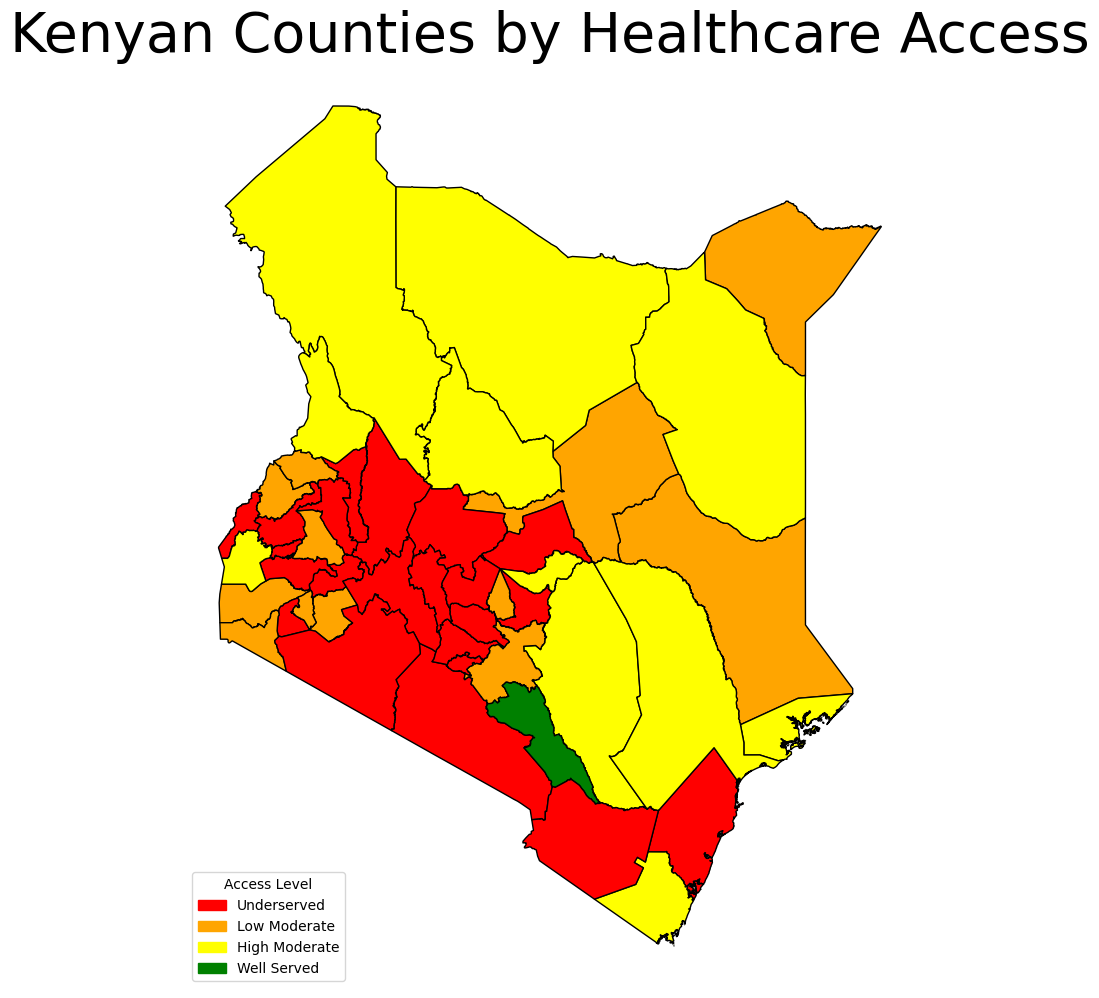

In [32]:
import matplotlib.pyplot as plt

# Plot using the color column
fig, ax = plt.subplots(figsize=(10, 12))
Final_data.plot(ax=ax, color=Final_data["color"], edgecolor="black")

# Optional: Add a legend manually
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in access_colors.items()]
ax.legend(handles=legend_patches, title="Access Level", loc="lower left")

plt.title("Kenyan Counties by Healthcare Access", fontsize=40)
plt.axis("off")
plt.show()


In [ ]:
#Save the figure
fig.savefig("../data/output/Kenyan Counties by Healthcare Access Map.png")

In [33]:
# Convert GeoDataFrame to WGS84 coordinate system (EPSG:4326) for web mapping compatibility
Final_data = Final_data.to_crs(epsg=4326)

# Center the map on Kenya
m = folium.Map(location=[0.0236, 37.9062], zoom_start=6, tiles="CartoDB positron")

#Define styling for each county polygon on the map
def style_function(feature):
    return {
        "fillColor": feature["properties"]["color"], # - fillColor: uses the color assigned to each county based on access_flag
        "color": "black", # - color: sets border color to black
        "weight": 1,  # - weight: sets border thickness
        "fillOpacity": 0.7,  # - fillOpacity: controls transparency of the fill color

    }
    
# Convert GeoDataFrame to GeoJSON and add to map
folium.GeoJson(
    Final_data,
    style_function=style_function,
    tooltip=GeoJsonTooltip(fields=["county", "access_flag"], aliases=["county", "access_level"])
).add_to(m)

#Saving the mapping as an html file
m.save("kenya_counties_access_map1.html")
